In [7]:
%load_ext autoreload
%autoreload 2

In [42]:
import pandas as pd
import functions
from google.cloud import bigquery
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import yaml

with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

In [10]:
client = bigquery.Client()

In [31]:
mart_apps_summary = f"""
SELECT *
FROM `{config['tables']['mart_apps_summary']}`
"""
df = client.query(mart_apps_summary).to_dataframe()

In [39]:
# Dataset Overview
display(df.shape)
print()
display(df.info())
print()
display(df.isnull().sum())
print()
display(df.describe())

(9659, 10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   app                  9659 non-null   object 
 1   category             9659 non-null   object 
 2   app_type             9658 non-null   object 
 3   rating               8196 non-null   float64
 4   installs             9659 non-null   Int64  
 5   price                9659 non-null   float64
 6   review_count         816 non-null    Int64  
 7   avg_sentiment        816 non-null    float64
 8   positive_review_pct  816 non-null    float64
 9   is_paid              9659 non-null   boolean
dtypes: Int64(2), boolean(1), float64(4), object(3)
memory usage: 717.0+ KB


None

app                       0
category                  0
app_type                  1
rating                 1463
installs                  0
price                     0
review_count           8843
avg_sentiment          8843
positive_review_pct    8843
is_paid                   0
dtype: int64

,rating,installs,price,review_count,avg_sentiment,positive_review_pct
count,8196.000000,9659.0,9659.000000,816.0,816.000000,816.000000
mean,4.173267,7798170.248162,1.097231,44.030637,0.200519,0.647158
std,0.536253,53769728.818071,16.851618,37.878823,0.161432,0.183044
min,1.000000,0.0,0.000000,1.0,-0.500000,0.000000
25%,4.000000,1000.0,0.000000,28.0,0.082372,0.538462
50%,4.300000,100000.0,0.000000,37.0,0.198221,0.666667
75%,4.500000,1000000.0,0.000000,40.0,0.299261,0.769231
max,5.000000,1000000000.0,400.000000,312.0,1.000000,1.000000


In [ ]:
# ==================================================================================================================================
# Data Integration Limitation
# - Approximately 94% of applications in the review dataset were successfully matched with the app metadata table.
# - A small subset of applications could not be linked due to inconsistencies in app naming conventions across the original datasets.
# 
# Insights
# 1.App installs are highly right-skewed, with a small number 
# of applications accounting for a disproportionately large share of total downloads.
# 
# 2.User ratings are heavily concentrated between 4.0 and 4.5, 
# indicating generally positive evaluations across most applications.
# 
# 3.The app marketplace is overwhelmingly dominated by free applications, 
# while paid apps form a small long-tail segment with highly variable pricing.
# 
# hypothesis 1 : free apps have high installs
# hypothesis 2 : apps with high installs might not have better sentiment
# hypothesis 3 : certain apps, such as Education and Health apps, have higher sentiment
# ==================================================================================================================================

In [40]:
# ==================================================================================================================================
# Distribution Analysis
# ==================================================================================================================================

<Axes: xlabel='log_installs', ylabel='Count'>

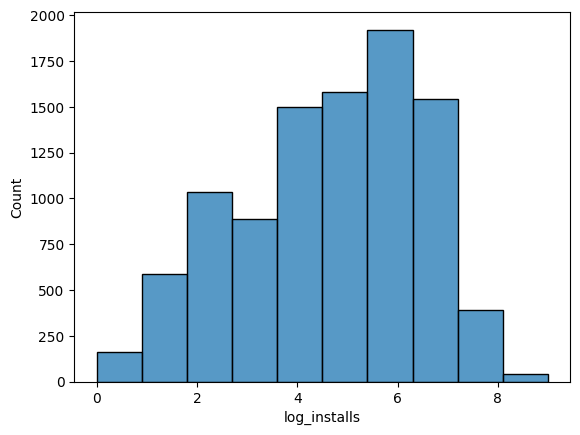

In [49]:
df["log_installs"] = np.log10(df["installs"] + 1)

sns.histplot(df["log_installs"], bins=10)

In [ ]:
# App installs exhibit a highly discrete and right-skewed distribution, reflecting 
# the bucketed install ranges used by the Google Play Store. 
# Most applications cluster within lower-to-mid download tiers, while only a small subset achieves massive adoption.

Text(0.5, 1.0, 'Distribution of App Ratings')

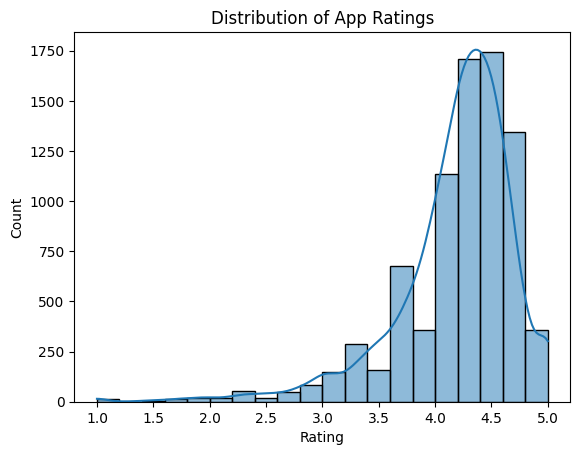

In [50]:
sns.histplot(df["rating"], bins=20, kde=True)

plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of App Ratings")

In [ ]:
# Distribution of App Ratings
# App ratings are strongly concentrated in the upper range, with most applications receiving scores between 4.0 and 4.5.
# The distribution is left-skewed, indicating that poorly rated applications are relatively rare within the dataset.
# This limited variance suggests that ratings alone may not fully explain differences in app popularity or install volume.

Text(0.5, 1.0, 'Distribution of Review Counts')

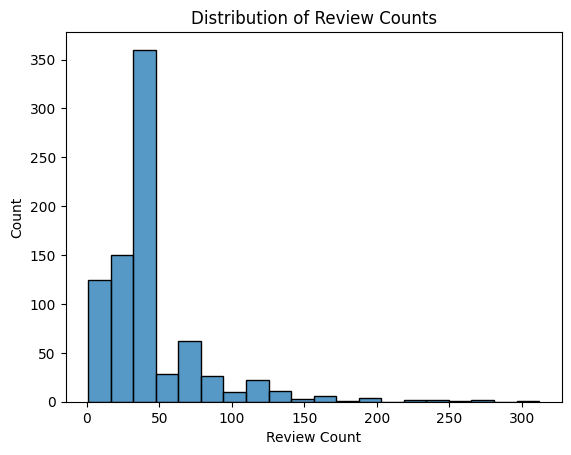

In [48]:
sns.histplot(df["review_count"], bins=20)

plt.xlabel("Review Count")
plt.ylabel("Count")
plt.title("Distribution of Review Counts")

Text(0.5, 1.0, 'Distribution of Log Review Counts')

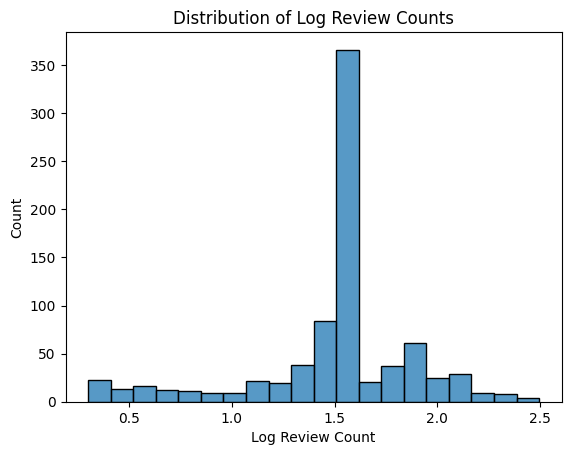

In [53]:
df["log_review_count"] = np.log10(df["review_count"] + 1)
sns.histplot(df["log_review_count"], bins=20)

plt.xlabel("Log Review Count")
plt.ylabel("Count")
plt.title("Distribution of Log Review Counts")

In [ ]:
# Review activity is unevenly distributed across applications, with most apps receiving relatively few
# sampled reviews while a smaller subset generates substantially higher engagement.
# After log transformation, the review count distribution becomes more interpretable, revealing a concentration
# of applications within moderate engagement levels.

Text(0.5, 1.0, 'Rating vs Log Installs')

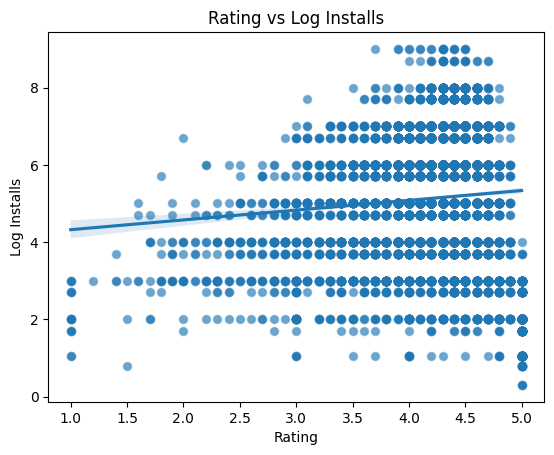

In [54]:
sns.scatterplot(
    data=df,
    x="rating",
    y="log_installs",
    alpha=0.5
)

sns.regplot(
    data=df,
    x="rating",
    y="log_installs",
    scatter_kws={"alpha":0.3}
)

plt.xlabel("Rating")
plt.ylabel("Log Installs")
plt.title("Rating vs Log Installs")

In [ ]:
# Rating vs Installs
# Although higher-rated applications tend to achieve slightly greater install volumes on average, the relationship appears relatively weak. 
# Applications with similar ratings can exhibit dramatically different adoption levels, suggesting that 
# factors beyond user ratings play a major role in app popularity.

In [ ]:
# ==================================================================================================================================
# Free vs Paid
# ==================================================================================================================================

Text(0.5, 1.0, 'Log Installs by App Type')

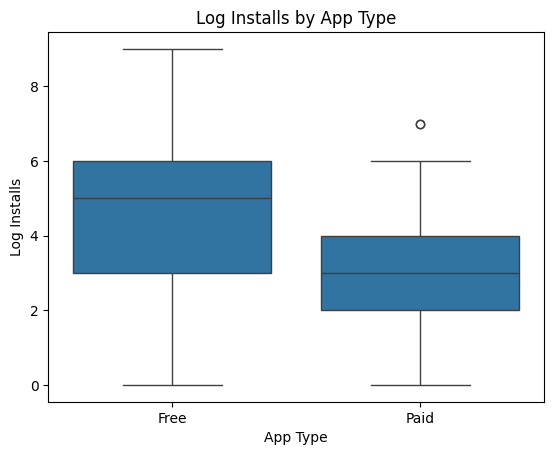

In [55]:
sns.boxplot(
    data=df,
    x="app_type",
    y="log_installs"
)

plt.xlabel("App Type")
plt.ylabel("Log Installs")
plt.title("Log Installs by App Type")

Text(0.5, 1.0, 'Ratings by App Type')

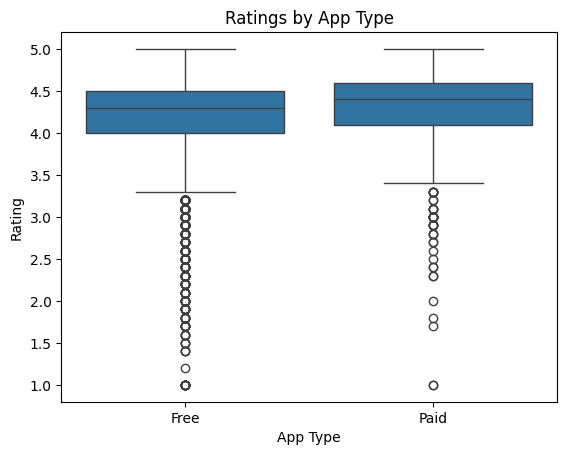

In [56]:
sns.boxplot(
    data=df,
    x="app_type",
    y="rating"
)

plt.xlabel("App Type")
plt.ylabel("Rating")
plt.title("Ratings by App Type")

Text(0.5, 1.0, 'Sentiment by App Type')

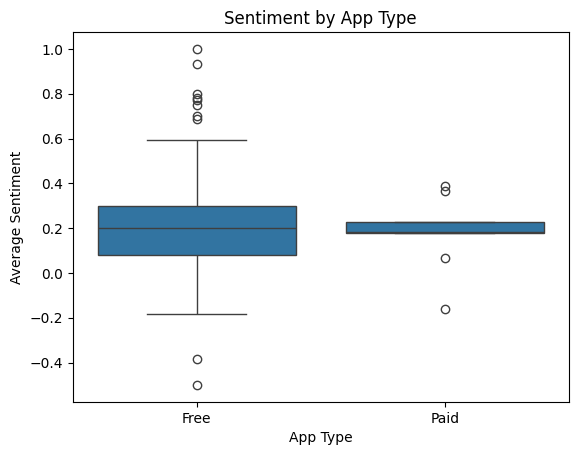

In [57]:
sns.boxplot(
    data=df,
    x="app_type",
    y="avg_sentiment"
)

plt.xlabel("App Type")
plt.ylabel("Average Sentiment")
plt.title("Sentiment by App Type")

In [ ]:
# Free apps dominate user acquisition.
# Paid apps maintain slightly higher and more consistent ratings.
# Free apps exhibit greater variability in both popularity and user sentiment.

In [ ]:
# ==================================================================================================================================
# Category Analysis
# ==================================================================================================================================

Text(0.5, 1.0, 'Median Installs by Category')

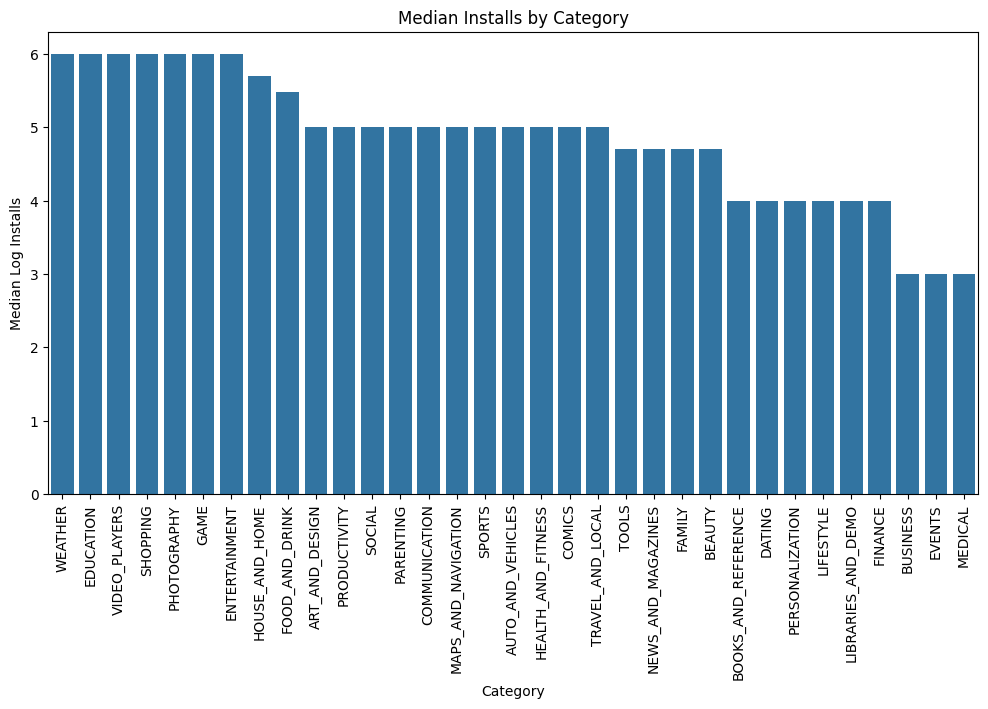

In [58]:
category_installs = (
    df.groupby("category")["installs"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_installs.index,
    y=np.log10(category_installs.values + 1)
)

plt.xticks(rotation=90)

plt.xlabel("Category")
plt.ylabel("Median Log Installs")
plt.title("Median Installs by Category")

Text(0.5, 1.0, 'Ratings by Category')

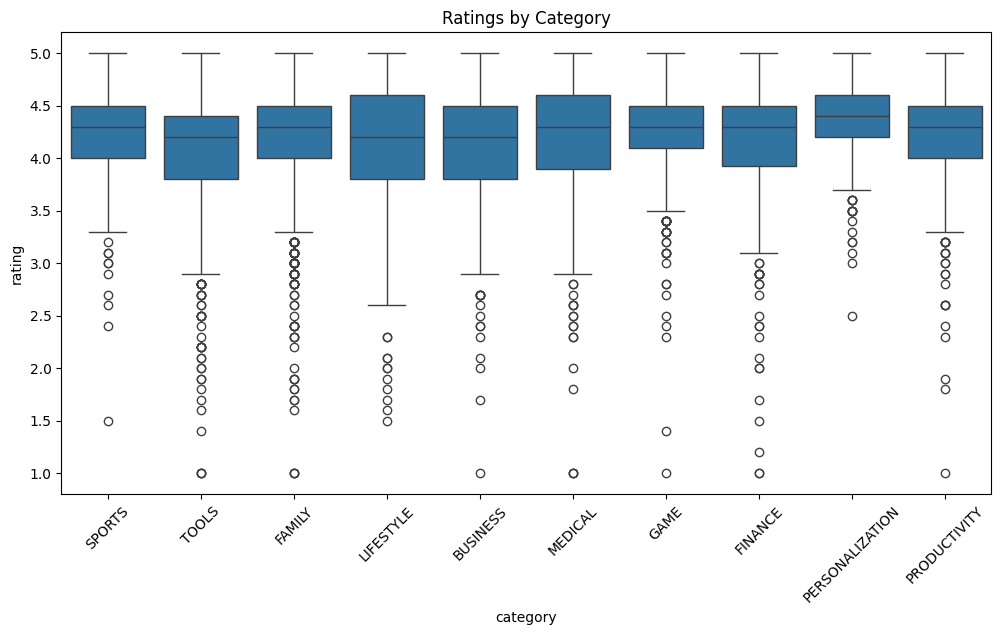

In [59]:
top_categories = (
    df["category"]
    .value_counts()
    .head(10)
    .index
)

top_df = df[df["category"].isin(top_categories)]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=top_df,
    x="category",
    y="rating"
)

plt.xticks(rotation=45)

plt.title("Ratings by Category")

Text(0.5, 1.0, 'Sentiment by Category')

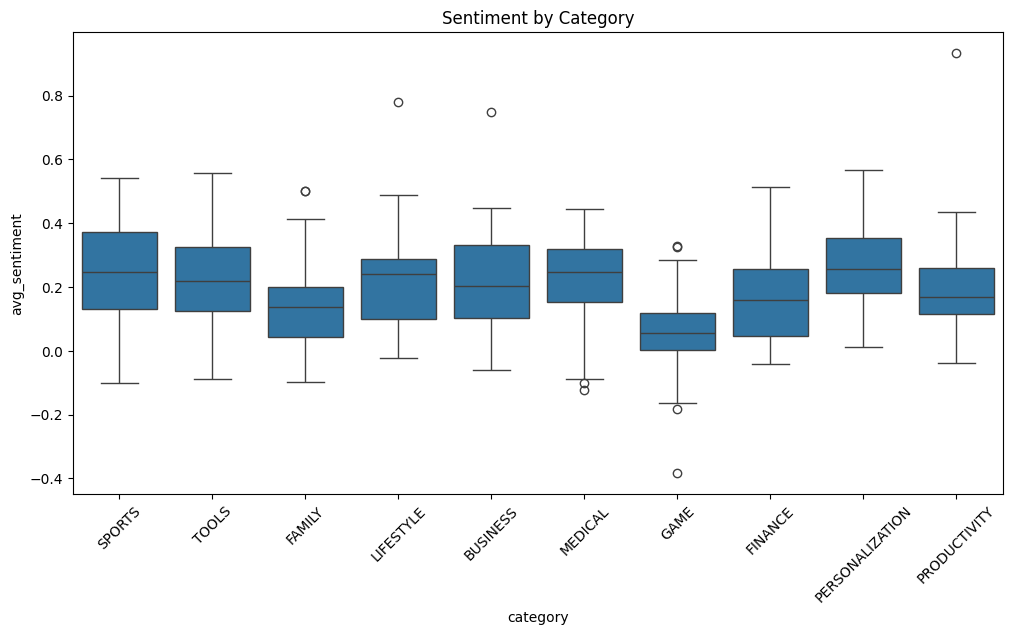

In [60]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=top_df,
    x="category",
    y="avg_sentiment"
)

plt.xticks(rotation=45)

plt.title("Sentiment by Category")

In [ ]:
# - Different app categories exhibit substantially different adoption patterns.
# - High-install categories do not necessarily achieve the strongest user sentiment.
# - Game apps generate relatively weaker sentiment despite maintaining competitive ratings, 
#   suggesting that star ratings may not fully capture user satisfaction.
# - Ratings and sentiment are related but not identical measures of user satisfaction.

In [ ]:
# ==================================================================================================================================
# Correlation Analysis
# ==================================================================================================================================

Text(0.5, 1.0, 'Correlation Matrix')

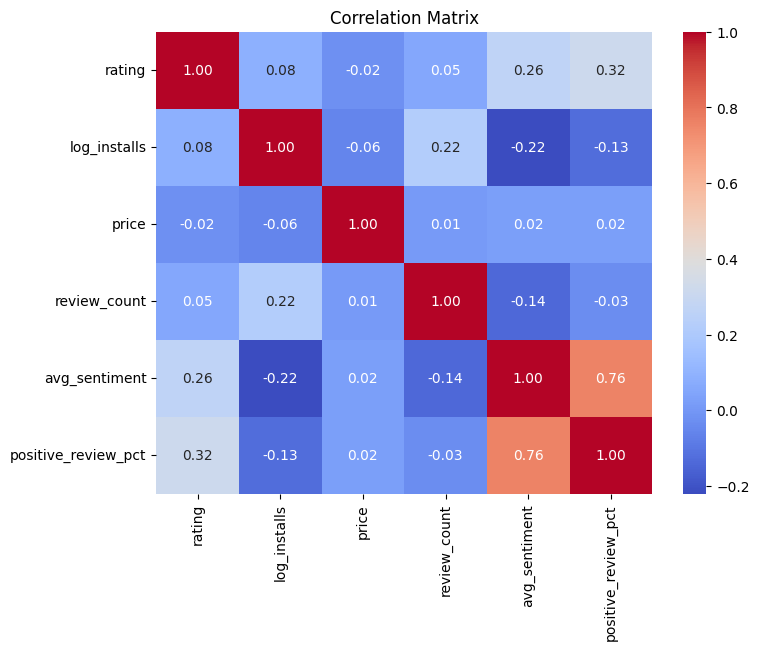

In [61]:
corr_df = df[
    [
        "rating",
        "log_installs",
        "price",
        "review_count",
        "avg_sentiment",
        "positive_review_pct"
    ]
]

corr_matrix = corr_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

In [ ]:
# Conclusion

In [ ]:
# Recommendations/Next steps